# 03 — Split-Ticket Analysis
**Ubon Ratchathani Constituency 10** | Data Science Project 2025/2

Comparing constituency vs party-list vote share to identify
which parties gained or lost votes between the two ballots.

- Group A (6 parties with constituency candidates): compute party-list premium = party-list% - constituency%
- Group B (51 parties without candidates): party-list only — where did split-ticket votes flow?

## 0 · Imports & Config

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

RAW  = Path('../data-final')
OUT  = Path('../data-processed/3')
OUT1  = Path('../data-processed/1')
FIG  = Path('../figures')
FIG.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

df_const  = pd.read_csv(OUT1 / 'constituency_station.csv')
df_party  = pd.read_csv(OUT1 / 'partylist_station.csv')
cand_map  = pd.read_csv(OUT1 / 'candidate_mapping.csv')
party_map = pd.read_csv(OUT1 / 'party_mapping.csv')

print('Loaded OK')

Loaded OK


In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Use a font that supports Thai — try system fonts first
thai_fonts = ['Tahoma', 'Arial Unicode MS', 'Noto Sans Thai', 'TH Sarabun New', 'FreeSans']

available = [f.name for f in fm.fontManager.ttflist]
chosen = next((f for f in thai_fonts if f in available), None)

if chosen:
    plt.rcParams['font.family'] = chosen
    print(f'Using font: {chosen}')
else:
    print('No Thai font found — labels may be garbled')
    print('Available fonts sample:', available[:10])

Using font: Tahoma


## 1 · Overall Vote Shares

Compute % for each candidate (constituency) and each party (party-list).
Use election_day stations only to keep the comparison fair
(advance_out stations don't always have both ballots).

In [3]:
# --- Constituency ---
const_ed = df_const[df_const['station_type'] == 'election_day']
total_const_votes = const_ed['score'].sum() / 6  # 6 candidates per station → divide to get unique voters

const_total = (
    const_ed
    .groupby(['cand_number', 'candidate_name', 'party_name', 'color_hex'])['score']
    .sum()
    .reset_index()
    .rename(columns={'score': 'const_votes'})
)
const_total['const_%'] = (const_total['const_votes'] / const_total['const_votes'].sum() * 100).round(2)

# --- Party-list ---
party_ed = df_party[df_party['station_type'] == 'election_day']
total_party_votes = party_ed['score'].sum() / 57  # 57 parties per station

party_total = (
    party_ed
    .groupby(['party_number', 'party_name'])['score']
    .sum()
    .reset_index()
    .rename(columns={'score': 'party_votes'})
)
party_total['party_%'] = (party_total['party_votes'] / party_total['party_votes'].sum() * 100).round(2)

print(f'Total constituency voters (est.) : {total_const_votes:,.0f}')
print(f'Total party-list voters (est.)   : {total_party_votes:,.0f}')
print(f'Difference                       : {total_const_votes - total_party_votes:,.0f}')

Total constituency voters (est.) : 11,278
Total party-list voters (est.)   : 1,616
Difference                       : 9,662


## 2 · Group A — Parties With Constituency Candidates

Map each candidate's party to its party-list number,
then compute party-list premium = party-list% - constituency%.
Positive = party gained votes in ballot 2.
Negative = party lost votes in ballot 2 (people split away).

In [4]:
# Manual mapping: party_name → party_list number
# Based on candidate_mapping + party_list_mapping
group_a_map = {
    'ภูมิใจไทย':      37,
    'เพื่อไทรวมพลัง': 21,
    'เพื่อไทย':       9,
    'พลังประชารัฐ':   43,
    'ประชาชน':        46,
    'ประชาธิปัตย์':   27,
}

rows = []
for _, cand in const_total.iterrows():
    pname      = cand['party_name']
    party_num  = group_a_map.get(pname)
    const_pct  = cand['const_%']
    color      = cand['color_hex']

    if party_num:
        pm = party_total[party_total['party_number'] == party_num]
        party_pct = pm['party_%'].values[0] if len(pm) else 0.0
    else:
        party_pct = 0.0

    rows.append({
        'party_name':   pname,
        'cand_number':  cand['cand_number'],
        'candidate_name': cand['candidate_name'],
        'color_hex':    color,
        'const_votes':  cand['const_votes'],
        'const_%':      const_pct,
        'party_votes':  party_total[party_total['party_number'] == party_num]['party_votes'].values[0]
                        if party_num and len(party_total[party_total['party_number'] == party_num]) else 0,
        'party_%':      party_pct,
        'premium':      round(party_pct - const_pct, 2),
    })

group_a = pd.DataFrame(rows).sort_values('premium')

print('=== Group A: Party-list Premium ===')
print(group_a[['party_name', 'candidate_name', 'const_%', 'party_%', 'premium']].to_string(index=False))

=== Group A: Party-list Premium ===
    party_name          candidate_name  const_%  party_%  premium
เพื่อไทรวมพลัง    นายสมศักดิ์ บุญประชม    82.59    39.91   -42.68
     ภูมิใจไทย          นายเกษม ฉิมพลี     4.15     1.30    -2.85
  พลังประชารัฐ นางสาวมิลิณ กำเนิดสิงห์     1.21     0.54    -0.67
      เพื่อไทย       นายวัชรพล เชื้อคง     7.46     6.81    -0.65
  ประชาธิปัตย์            นายยิ่ง ภูผา     0.35     0.71     0.36
       ประชาชน    นายสิโรตม์ แสนทวีสุข     4.24     5.20     0.96


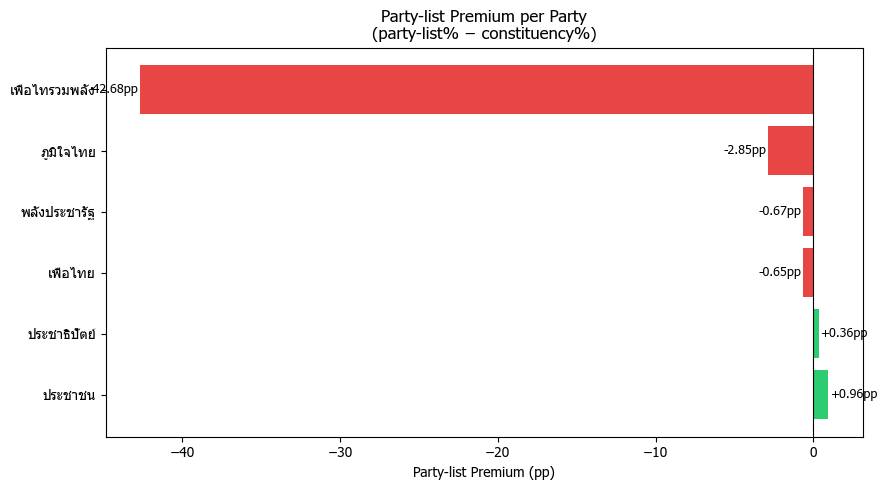

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#e84545' if p < 0 else '#2ecc71' for p in group_a['premium']]
bars = ax.barh(group_a['party_name'], group_a['premium'], color=colors)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Party-list Premium (pp)')
ax.set_title('Party-list Premium per Party\n(party-list% − constituency%)')

for bar, val in zip(bars, group_a['premium']):
    offset = 0.1 if val >= 0 else -0.1
    ha     = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.2f}pp', va='center', ha=ha, fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG / 'group_a_premium.png', dpi=150)
plt.show()

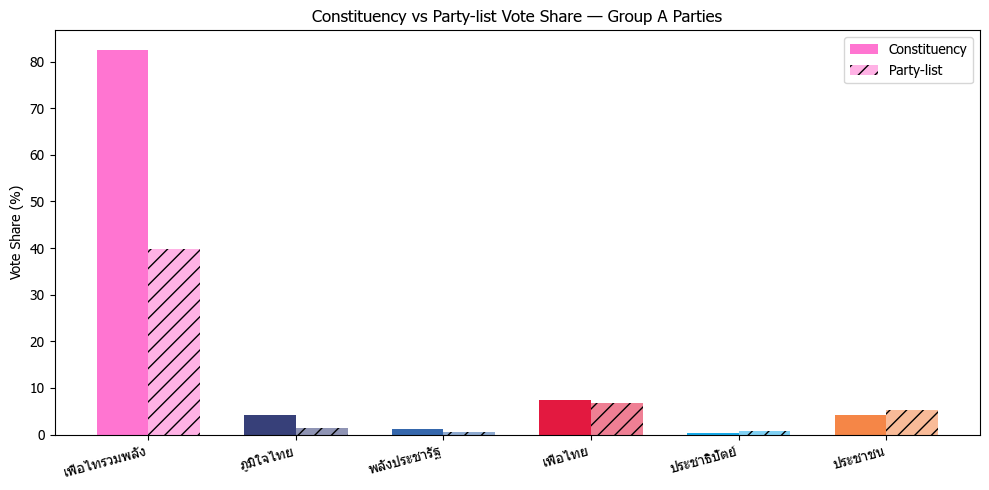

In [8]:
# Side-by-side bar: constituency% vs party-list%
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(group_a))
w = 0.35

ax.bar(x - w/2, group_a['const_%'],  width=w,
       color=group_a['color_hex'].tolist(), label='Constituency', alpha=0.9)
ax.bar(x + w/2, group_a['party_%'],  width=w,
       color=group_a['color_hex'].tolist(), label='Party-list', alpha=0.5, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(group_a['party_name'], rotation=15, ha='right')
ax.set_ylabel('Vote Share (%)')
ax.set_title('Constituency vs Party-list Vote Share — Group A Parties')
ax.legend()
plt.tight_layout()
plt.savefig(FIG / 'group_a_side_by_side.png', dpi=150)
plt.show()

## 3 · Group B — Parties Without Constituency Candidates

These parties only appear in the party-list ballot.
Their votes come entirely from split-ticket voters
(people who voted for a Group A candidate in ballot 1).
Shows where "overflow" votes went.

In [9]:
group_a_party_nums = list(group_a_map.values())

group_b = (
    party_total[~party_total['party_number'].isin(group_a_party_nums)]
    .sort_values('party_votes', ascending=False)
    .reset_index(drop=True)
)

# Total split-ticket pool = total party-list votes going to Group B
group_b_total = group_b['party_votes'].sum()
group_b['share_of_split_%'] = (group_b['party_votes'] / group_b_total * 100).round(2)

print(f'Total votes flowing to Group B parties: {group_b_total:,}')
print(f'That is {group_b_total / total_party_votes * 100:.1f}% of all party-list votes\n')
print('=== Top 15 Group B Parties ===')
print(group_b[['party_number', 'party_name', 'party_votes', 'party_%', 'share_of_split_%']]
      .head(15).to_string(index=False))

Total votes flowing to Group B parties: 41,932
That is 2595.4% of all party-list votes

=== Top 15 Group B Parties ===
 party_number                  party_name  party_votes  party_%  share_of_split_%
           57              พลังไทยรักชาติ         3417     3.71              8.15
           22                   ก้าวอิสระ         2506     2.72              5.98
            2                เพื่อชาติไทย         2164     2.35              5.16
           56              เพื่อบ้านเมือง         2094     2.27              4.99
           20                     ฟิวชั่น         1705     1.85              4.07
           48                 ไทยสร้างไทย         1583     1.72              3.78
           47                    ประชาไทย         1362     1.48              3.25
           11                    เศรษฐกิจ         1356     1.47              3.23
           50               ประชาอาสาชาติ         1347     1.46              3.21
           52 เครือข่ายชาวนาแห่งประเทศไทย         1216     1.

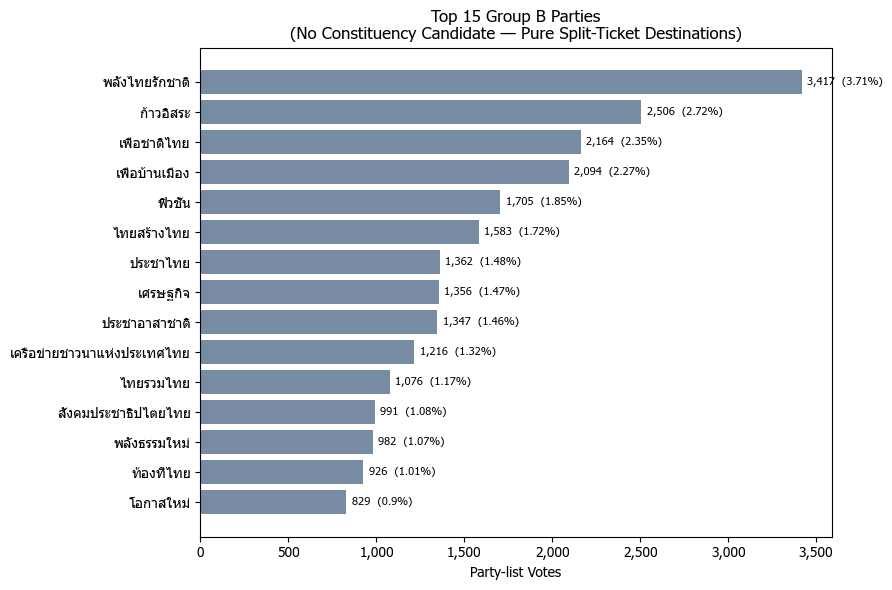

In [10]:
top15 = group_b.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15['party_name'], top15['party_votes'], color='#778ca3')
ax.set_xlabel('Party-list Votes')
ax.set_title('Top 15 Group B Parties\n(No Constituency Candidate — Pure Split-Ticket Destinations)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, (_, row) in enumerate(top15.iterrows()):
    ax.text(row['party_votes'] + 30, i,
            f"{row['party_votes']:,}  ({row['party_%']}%)",
            va='center', fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG / 'group_b_destinations.png', dpi=150)
plt.show()

## 4 · Full Picture — All Parties Ranked by Party-list Vote Share

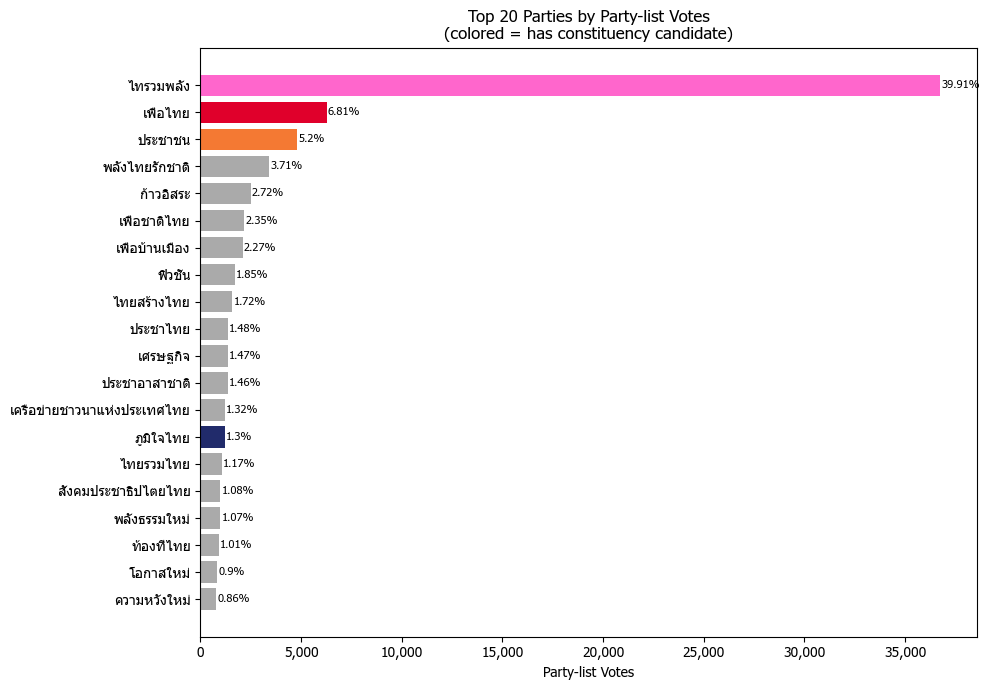

In [11]:
# Tag each party as Group A or B
party_total['group'] = party_total['party_number'].apply(
    lambda n: 'A (has candidate)' if n in group_a_party_nums else 'B (no candidate)'
)

top20_all = party_total.sort_values('party_votes', ascending=False).head(20)

# Color: use candidate color for Group A, gray for Group B
a_color_lookup = {
    group_a_map[p]: group_a.loc[group_a['party_name'] == p, 'color_hex'].values[0]
    for p in group_a_map
    if len(group_a.loc[group_a['party_name'] == p]) > 0
}
bar_colors = [a_color_lookup.get(n, '#aaaaaa') for n in top20_all['party_number']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20_all['party_name'], top20_all['party_votes'], color=bar_colors)
ax.set_xlabel('Party-list Votes')
ax.set_title('Top 20 Parties by Party-list Votes\n(colored = has constituency candidate)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, (_, row) in enumerate(top20_all.iterrows()):
    ax.text(row['party_votes'] + 50, i,
            f"{row['party_%']}%", va='center', fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG / 'all_parties_partylist.png', dpi=150)
plt.show()

## 5 · Export

In [16]:
group_a.to_csv(OUT / 'split_ticket_group_a.csv', index=False, encoding='utf-8-sig')
group_b.to_csv(OUT / 'split_ticket_group_b.csv', index=False, encoding='utf-8-sig')
party_total.to_csv(OUT / 'partylist_overall.csv', index=False, encoding='utf-8-sig')

print('Exported OK')

Exported OK


## Summary

| File | Description |
|------|-------------|
| `split_ticket_group_a.csv` | 6 parties with candidates — premium/deficit vs constituency |
| `split_ticket_group_b.csv` | 51 parties without candidates — split-ticket destinations |
| `partylist_overall.csv` | All 57 parties party-list totals |

**Next:** `04_advance_vs_electionday.ipynb`